In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Load the data
df = pd.read_csv('c.csv')

# Convert created_at to datetime
df['created_at'] = pd.to_datetime(df['created_at'])

# Basic data info
print("Dataset Overview:")
print(f"Total sessions: {len(df)}")
print(f"Date range: {df['created_at'].min()} to {df['created_at'].max()}")
print(f"Unique students: {df['student_id'].nunique()}")
print(f"Game modes: {df['game_mode'].value_counts()}")
print("\n" + "="*50 + "\n")

Dataset Overview:
Total sessions: 261
Date range: 2025-06-04 07:55:25.963134 to 2025-06-04 08:30:15.313652
Unique students: 16
Game modes: game_mode
practice    130
computer     67
pvp          64
Name: count, dtype: int64




In [2]:
# =============================================================================
# PRACTICE MODE ANALYSIS
# =============================================================================
practice_df = df[df['game_mode'] == 'practice'].copy()

print("PRACTICE MODE ANALYSIS")
print("="*30)
print(f"Total practice sessions: {len(practice_df)}")
print(f"Unique students in practice: {practice_df['student_id'].nunique()}")

# Practice mode metrics
practice_df['accuracy'] = practice_df['correct_answers'] / (practice_df['correct_answers'] + practice_df['wrong_answers'])
practice_df['time_per_question'] = practice_df['time_taken'] / practice_df['total_questions']
practice_df['attempts_per_question'] = (practice_df['correct_answers'] + practice_df['wrong_answers']) / practice_df['total_questions']

print(f"\nPractice Mode Statistics:")
print(f"Average time per session: {practice_df['time_taken'].mean():.1f} seconds")
print(f"Average time per question: {practice_df['time_per_question'].mean():.1f} seconds")
print(f"Average accuracy: {practice_df['accuracy'].mean():.2%}")
print(f"Average attempts per question: {practice_df['attempts_per_question'].mean():.1f}")
print(f"Average wrong attempts per session: {practice_df['wrong_answers'].mean():.1f}")


PRACTICE MODE ANALYSIS
Total practice sessions: 130
Unique students in practice: 15

Practice Mode Statistics:
Average time per session: 89.9 seconds
Average time per question: 9.0 seconds
Average accuracy: 67.70%
Average attempts per question: 1.7
Average wrong attempts per session: 6.6


In [4]:
# =============================================================================
# COMPUTER MODE ANALYSIS
# =============================================================================
computer_df = df[df['game_mode'] == 'computer'].copy()

print(f"\n\nCOMPUTER MODE ANALYSIS")
print("="*30)
print(f"Total computer sessions: {len(computer_df)}")
print(f"Unique students in computer mode: {computer_df['student_id'].nunique()}")

# Computer mode metrics
computer_df['questions_per_second'] = computer_df['total_questions'] / computer_df['time_taken']
computer_df['accuracy'] = computer_df['correct_answers'] / computer_df['total_questions']
win_rate_computer = (computer_df['winner'] == 't').mean()

print(f"\nComputer Mode Statistics:")
print(f"Average time per session: {computer_df['time_taken'].mean():.1f} seconds")
print(f"Average questions shown: {computer_df['total_questions'].mean():.1f}")
print(f"Average questions per second: {computer_df['questions_per_second'].mean():.2f}")
print(f"Average student accuracy: {computer_df['accuracy'].mean():.2%}")
print(f"Student win rate vs computer: {win_rate_computer:.2%}")
print(f"Average points when winning: {computer_df[computer_df['winner'] == 't']['points'].mean():.1f}")




COMPUTER MODE ANALYSIS
Total computer sessions: 67
Unique students in computer mode: 15

Computer Mode Statistics:
Average time per session: 44.5 seconds
Average questions shown: 14.8
Average questions per second: 0.65
Average student accuracy: 79.15%
Student win rate vs computer: 97.01%
Average points when winning: 4.9


In [5]:
# =============================================================================
# PVP MODE ANALYSIS
# =============================================================================
pvp_df = df[df['game_mode'] == 'pvp'].copy()

print(f"\n\nPVP MODE ANALYSIS")
print("="*30)
print(f"Total PVP sessions: {len(pvp_df)}")
print(f"Unique students in PVP: {pvp_df['student_id'].nunique()}")

# PVP metrics
pvp_df['questions_per_second'] = pvp_df['total_questions'] / pvp_df['time_taken']
pvp_df['accuracy'] = pvp_df['correct_answers'] / pvp_df['total_questions']
pvp_wins = pvp_df[pvp_df['winner'] == 't']
pvp_losses = pvp_df[pvp_df['winner'] == 'f']

print(f"\nPVP Mode Statistics:")
print(f"Average time per session: {pvp_df['time_taken'].mean():.1f} seconds")
print(f"Average questions shown: {pvp_df['total_questions'].mean():.1f}")
print(f"Average questions per second: {pvp_df['questions_per_second'].mean():.2f}")
print(f"Average accuracy: {pvp_df['accuracy'].mean():.2%}")
print(f"Win rate: {(pvp_df['winner'] == 't').mean():.2%}")

print(f"\nPVP Winners vs Losers:")
print(f"Winners - Avg correct: {pvp_wins['correct_answers'].mean():.1f}, Avg accuracy: {pvp_wins['accuracy'].mean():.2%}")
print(f"Losers - Avg correct: {pvp_losses['correct_answers'].mean():.1f}, Avg accuracy: {pvp_losses['accuracy'].mean():.2%}")




PVP MODE ANALYSIS
Total PVP sessions: 64
Unique students in PVP: 16

PVP Mode Statistics:
Average time per session: 102.1 seconds
Average questions shown: 31.7
Average questions per second: 0.34
Average accuracy: 46.63%
Win rate: 65.62%

PVP Winners vs Losers:
Winners - Avg correct: 16.5, Avg accuracy: 52.65%
Losers - Avg correct: 12.7, Avg accuracy: 35.14%


In [6]:
# =============================================================================
# COMPARATIVE ANALYSIS
# =============================================================================
print(f"\n\nCOMPARATIVE ANALYSIS")
print("="*30)

# Time analysis
print("Average Session Duration by Mode:")
for mode in ['practice', 'computer', 'pvp']:
    avg_time = df[df['game_mode'] == mode]['time_taken'].mean()
    print(f"{mode.capitalize()}: {avg_time:.1f} seconds")

# Performance comparison
print(f"\nAccuracy Comparison:")
practice_acc = practice_df['accuracy'].mean()
computer_acc = computer_df['accuracy'].mean()
pvp_acc = pvp_df['accuracy'].mean()

print(f"Practice: {practice_acc:.2%}")
print(f"Computer: {computer_acc:.2%}")
print(f"PVP: {pvp_acc:.2%}")

# =============================================================================
# STUDENT PERFORMANCE ANALYSIS
# =============================================================================
print(f"\n\nSTUDENT PERFORMANCE ANALYSIS")
print("="*35)

# Student activity by mode
student_activity = df.groupby(['student_id', 'game_mode']).size().unstack(fill_value=0)
print("Student Activity by Mode:")
print(student_activity.describe())

# Top performers
print(f"\nTop 5 Students by Practice Accuracy:")
if len(practice_df) > 0:
    practice_student_stats = practice_df.groupby('student_id').agg({
        'accuracy': 'mean',
        'session_id': 'count',
        'time_per_question': 'mean'
    }).round(3)
    practice_student_stats.columns = ['avg_accuracy', 'sessions', 'avg_time_per_q']
    top_practice = practice_student_stats.sort_values('avg_accuracy', ascending=False).head()
    print(top_practice)

print(f"\nTop 5 Students by Computer Mode Win Rate:")
if len(computer_df) > 0:
    computer_student_stats = computer_df.groupby('student_id').agg({
        'winner': lambda x: (x == 't').mean(),
        'session_id': 'count',
        'accuracy': 'mean'
    }).round(3)
    computer_student_stats.columns = ['win_rate', 'sessions', 'avg_accuracy']
    top_computer = computer_student_stats.sort_values('win_rate', ascending=False).head()
    print(top_computer)




COMPARATIVE ANALYSIS
Average Session Duration by Mode:
Practice: 89.9 seconds
Computer: 44.5 seconds
Pvp: 102.1 seconds

Accuracy Comparison:
Practice: 67.70%
Computer: 79.15%
PVP: 46.63%


STUDENT PERFORMANCE ANALYSIS
Student Activity by Mode:
game_mode  computer   practice        pvp
count      16.00000  16.000000  16.000000
mean        4.18750   8.125000   4.000000
std         2.50915   3.159641   1.788854
min         0.00000   0.000000   1.000000
25%         2.75000   6.750000   2.750000
50%         3.50000   8.000000   4.000000
75%         7.00000  10.000000   5.000000
max         7.00000  14.000000   7.000000

Top 5 Students by Practice Accuracy:
            avg_accuracy  sessions  avg_time_per_q
student_id                                        
39                 0.912         6          20.700
30                 0.899         6           5.817
49                 0.865         9           8.244
36                 0.745         7          10.686
43                 0.739       

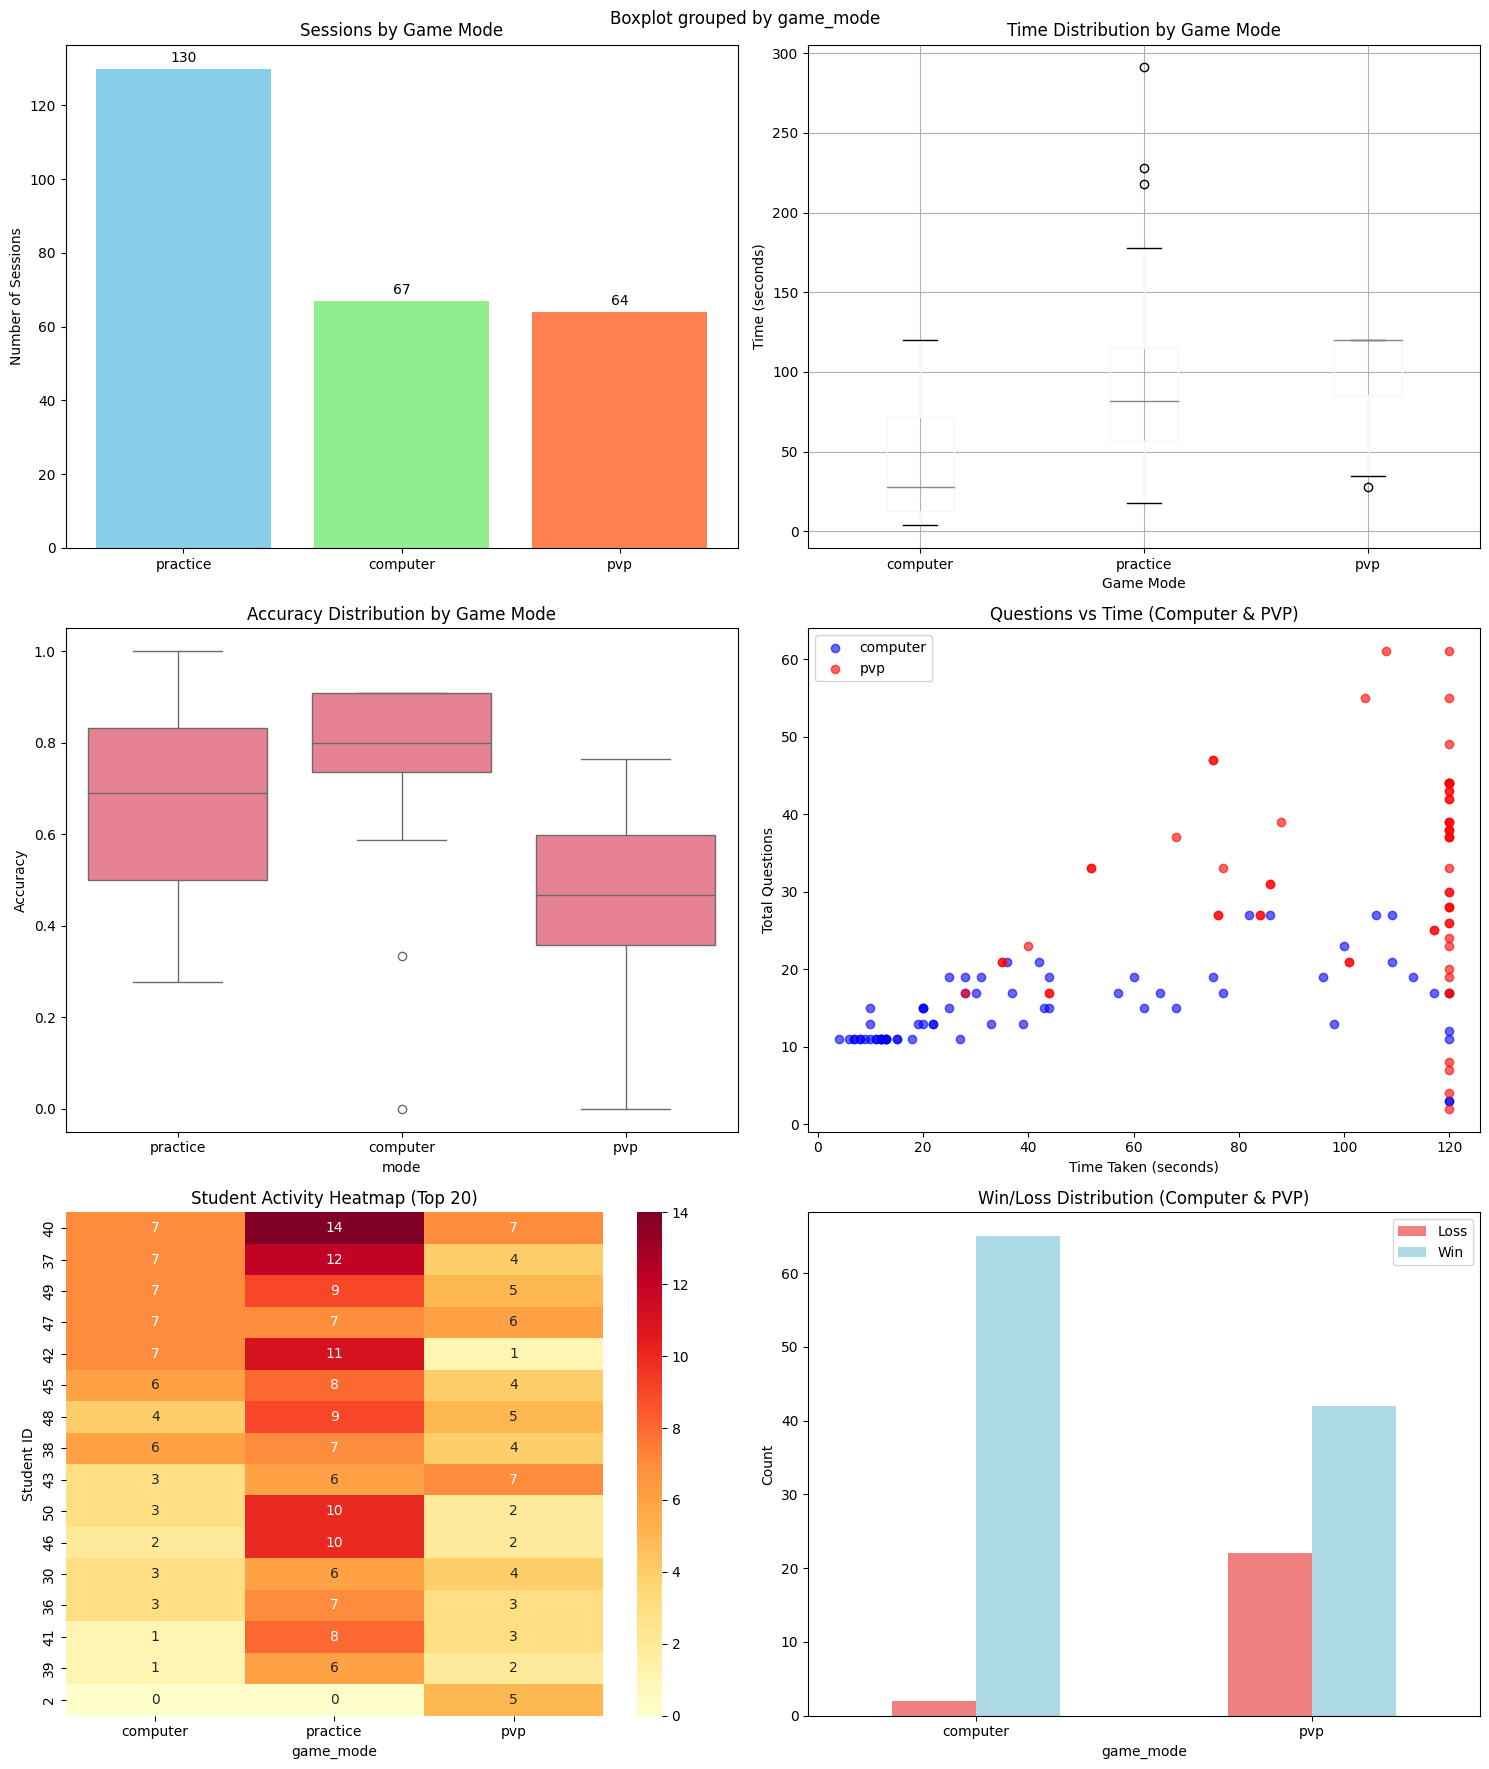

In [7]:
# =============================================================================
# VISUALIZATIONS
# =============================================================================

# Create figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.suptitle('Game Sessions Analysis Dashboard', fontsize=16, fontweight='bold')

# 1. Session count by mode
mode_counts = df['game_mode'].value_counts()
axes[0, 0].bar(mode_counts.index, mode_counts.values, color=['skyblue', 'lightgreen', 'coral'])
axes[0, 0].set_title('Sessions by Game Mode')
axes[0, 0].set_ylabel('Number of Sessions')
for i, v in enumerate(mode_counts.values):
    axes[0, 0].text(i, v + 1, str(v), ha='center', va='bottom')

# 2. Time distribution by mode
df.boxplot(column='time_taken', by='game_mode', ax=axes[0, 1])
axes[0, 1].set_title('Time Distribution by Game Mode')
axes[0, 1].set_ylabel('Time (seconds)')
axes[0, 1].set_xlabel('Game Mode')

# 3. Accuracy comparison
accuracy_data = []
for mode in ['practice', 'computer', 'pvp']:
    mode_df = df[df['game_mode'] == mode].copy()
    if mode == 'practice':
        mode_df['accuracy'] = mode_df['correct_answers'] / (mode_df['correct_answers'] + mode_df['wrong_answers'])
    else:
        mode_df['accuracy'] = mode_df['correct_answers'] / mode_df['total_questions']
    accuracy_data.extend([(mode, acc) for acc in mode_df['accuracy']])

accuracy_df = pd.DataFrame(accuracy_data, columns=['mode', 'accuracy'])
sns.boxplot(data=accuracy_df, x='mode', y='accuracy', ax=axes[1, 0])
axes[1, 0].set_title('Accuracy Distribution by Game Mode')
axes[1, 0].set_ylabel('Accuracy')

# 4. Questions vs Time scatter (Computer and PVP)
timed_modes = df[df['game_mode'].isin(['computer', 'pvp'])]
colors = {'computer': 'blue', 'pvp': 'red'}
for mode in ['computer', 'pvp']:
    mode_data = timed_modes[timed_modes['game_mode'] == mode]
    axes[1, 1].scatter(mode_data['time_taken'], mode_data['total_questions'], 
                      alpha=0.6, label=mode, color=colors[mode])
axes[1, 1].set_xlabel('Time Taken (seconds)')
axes[1, 1].set_ylabel('Total Questions')
axes[1, 1].set_title('Questions vs Time (Computer & PVP)')
axes[1, 1].legend()

# 5. Student activity heatmap
if len(student_activity) > 0:
    # Show top 20 most active students
    top_students = student_activity.sum(axis=1).nlargest(20).index
    student_subset = student_activity.loc[top_students]
    
    sns.heatmap(student_subset, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2, 0])
    axes[2, 0].set_title('Student Activity Heatmap (Top 20)')
    axes[2, 0].set_ylabel('Student ID')

# 6. Win/Loss analysis for competitive modes
competitive_df = df[df['game_mode'].isin(['computer', 'pvp'])]
win_loss_data = competitive_df.groupby(['game_mode', 'winner']).size().unstack(fill_value=0)
win_loss_data.plot(kind='bar', ax=axes[2, 1], color=['lightcoral', 'lightblue'])
axes[2, 1].set_title('Win/Loss Distribution (Computer & PVP)')
axes[2, 1].set_ylabel('Count')
axes[2, 1].legend(['Loss', 'Win'])
axes[2, 1].set_xticklabels(axes[2, 1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [8]:
# =============================================================================
# DETAILED INSIGHTS
# =============================================================================
print(f"\n\nDETAILED INSIGHTS")
print("="*25)

# Time efficiency
print("Time Efficiency Analysis:")
print(f"Practice mode: Students take {practice_df['time_per_question'].mean():.1f}s per question on average")
print(f"Computer mode: {computer_df['questions_per_second'].mean():.2f} questions per second")
print(f"PVP mode: {pvp_df['questions_per_second'].mean():.2f} questions per second")

# Learning patterns
print(f"\nLearning Patterns:")
practice_attempts = practice_df['attempts_per_question'].mean()
print(f"Students make {practice_attempts:.1f} attempts per question in practice mode")
print(f"This suggests {'good' if practice_attempts < 1.3 else 'room for improvement in'} question comprehension")

# Competitive performance
if len(computer_df) > 0 and len(pvp_df) > 0:
    print(f"\nCompetitive Performance:")
    comp_win_rate = (computer_df['winner'] == 't').mean()
    pvp_win_rate_final = (pvp_df['winner'] == 't').mean()
    print(f"Students perform {'better' if comp_win_rate > pvp_win_rate_final else 'worse'} against computer vs other students")
    print(f"Computer win rate: {comp_win_rate:.2%} vs PVP win rate: {pvp_win_rate_final:.2%}")

# Topic analysis
print(f"\nTopic Analysis:")
topic_performance = df.groupby(['topic_id', 'game_mode']).agg({
    'correct_answers': 'mean',
    'session_id': 'count'
}).round(2)
print("Average correct answers by topic and mode:")
print(topic_performance)

print(f"\n" + "="*50)
print("Analysis Complete!")
print("="*50)



DETAILED INSIGHTS
Time Efficiency Analysis:
Practice mode: Students take 9.0s per question on average
Computer mode: 0.65 questions per second
PVP mode: 0.34 questions per second

Learning Patterns:
Students make 1.7 attempts per question in practice mode
This suggests room for improvement in question comprehension

Competitive Performance:
Students perform better against computer vs other students
Computer win rate: 97.01% vs PVP win rate: 65.62%

Topic Analysis:
Average correct answers by topic and mode:
                    correct_answers  session_id
topic_id game_mode                             
8        computer             12.35          31
         practice             10.00          51
         pvp                  14.90          39
9        computer             11.00          36
         practice             10.00          79
         pvp                  15.64          25

Analysis Complete!
